# Prédire le CO₂ à partir des chevaux fiscaux et du caractère hybride

## Un cas d'usage concret : compléter un inventaire ancien incomplet
Une petite entreprise possède un inventaire de véhicules correspondant au catalogue de mars 2015. Certaines fiches indiquent les chevaux fiscaux et « hybride : oui/non », mais pas le CO₂. Le gestionnaire veut obtenir un ordre de grandeur provisoire et identifier les fiches qui nécessitent de retrouver la donnée officielle.

**Entrées :** `puiss_admin` (chevaux fiscaux, pas chevaux moteur) et `hybride`.
**Cible :** `co2_mixte`, émissions déclarées de CO₂ en g/km. C'est une régression supervisée.
**Sortie :** estimation, plage d'erreur indicative et nombre de modèles comparables dans l'entraînement.
**Décision :** préremplir une fiche en la marquant « estimée », ou demander la référence exacte du véhicule quand les données sont insuffisantes. Si le CNIT permet une recherche fiable dans le catalogue, utiliser d'abord cette donnée connue.

Le kilométrage sert seulement à convertir le résultat en scénario annuel : `g/km × km/an / 1 000 000 = tonnes/an`. Cette multiplication ne transforme pas une mesure d'homologation en émission réelle.

## Prendre du recul avant d'entraîner
- Le CO₂ renseigne un aspect de l'impact climatique. Il ne résume pas les NOx, particules, fabrication, carburant ou électricité en amont.
- Ce catalogue ancien ne valide pas une estimation pour un véhicule récent. Les 56 lignes sans cible CO₂, de code `EL`, ne peuvent pas servir à l'apprentissage supervisé ; elles ne doivent pas être assimilées aux autres véhicules non hybrides.
- « Hybride » regroupe plusieurs technologies. Les deux entrées ne décrivent ni le carburant, ni la masse, ni les conditions de conduite ou de recharge.
- Les variantes nombreuses d'un même modèle ne sont pas des observations indépendantes, ni un échantillon pondéré par les ventes.
- La formule historique de puissance fiscale incorporait déjà le CO₂ : `PA = CO₂ / 45 + (P / 40)^1,6`, avec P en kW et arrondi. Cela crée un lien administratif avec la cible. Le modèle peut aider à reconstituer une donnée manquante ; il n'établit pas un effet causal de la puissance ou de l'hybridation.

Sources : [description ADEME du catalogue](https://www.data.gouv.fr/datasets/emissions-de-co2-et-de-polluants-des-vehicules-commercialises-en-france), [formule historique, article 62 de la loi du 2 juillet 1998](https://www.legifrance.gouv.fr/loda/article_lc/LEGIARTI000006320193).

Exécuter ce notebook depuis le dossier de l'atelier. Dépendances : pandas, numpy, scikit-learn, matplotlib, joblib. Les notebooks précédents sont conservés.

In [1]:
from pathlib import Path
import json
import numbers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import joblib
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import StratifiedGroupKFold, GroupKFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sortie = Path('prediction_co2')
sortie.mkdir(exist_ok=True)
brut = pd.read_csv('donnees_nettoyees/vehicules_nettoyes.csv', sep=';')
colonnes = ['puiss_admin', 'hybride']
cible = 'co2_mixte'
donnees = brut.dropna(subset=colonnes + [cible, 'mrq_utac', 'mod_utac']).copy().reset_index(drop=True)
assert set(donnees.hybride.unique()) <= {'oui', 'non'}
assert donnees[cible].ge(0).all()
# Identité de groupe seulement pour l'évaluation, jamais comme entrée du modèle.
groupes = donnees['mrq_utac'] + ' | ' + donnees['mod_utac']
X, y = donnees[colonnes], donnees[cible]
print(f'{len(donnees)} lignes utilisables ; {len(brut) - len(donnees)} exclues sans imputation de cible.')
print(donnees.groupby('hybride')[cible].agg(['count', 'min', 'median', 'max']).to_string())

20824 lignes utilisables ; 56 exclues sans imputation de cible.
         count   min  median    max
hybride                            
non      19801  79.0   149.0  398.0
oui       1023  13.0   114.0  330.0


## Séparer les familles de véhicules avant tout apprentissage

Une famille est définie ici par la marque et le modèle UTAC. Toutes ses variantes restent dans la même partition, même si elles n'ont pas les mêmes caractéristiques. Cette règle réduit le risque de reconnaître dans le test des variantes déjà vues ; elle ne garantit pas que des noms UTAC différents n'utilisent pas une plateforme commune.

Cinq plis stratifiés sur le statut hybride sont construits avec une graine fixe. Le pli 0 sert de **test final**, le pli 1 de **calibration de l'erreur**, les trois autres d'**entraînement**. Les tailles ne sont pas exactement 20/20/60 %, car certaines familles contiennent beaucoup plus de lignes que d'autres. On ne recherche pas une séparation donnant de meilleurs scores.

In [2]:
plis = np.full(len(donnees), -1)
separateur = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
for numero, (_, indices) in enumerate(separateur.split(X, donnees.hybride, groupes)):
    plis[indices] = numero
train, calibration, test = plis >= 2, plis == 1, plis == 0
assert set(groupes[train]).isdisjoint(groupes[test])
assert set(groupes[train]).isdisjoint(groupes[calibration])
assert set(groupes[calibration]).isdisjoint(groupes[test])
repartition = []
for nom, masque in [('entraînement', train), ('calibration', calibration), ('test', test)]:
    for hybride in ['non', 'oui']:
        selection = masque & donnees.hybride.eq(hybride)
        repartition.append({'partition': nom, 'hybride': hybride,
                            'lignes': int(selection.sum()), 'familles': int(groupes[selection].nunique())})
print(pd.DataFrame(repartition).to_string(index=False))

   partition hybride  lignes  familles
entraînement     non   10504       239
entraînement     oui     592        28
 calibration     non    2989        92
 calibration     oui     358        11
        test     non    6308        68
        test     oui      73         9


## Comparer avec une référence simple

On compare une prédiction constante (médiane), une régression linéaire et deux forêts limitées en profondeur. Une forêt n'est pas supposée meilleure par principe. Le choix minimise la MAE moyenne sur quatre plis internes regroupés par famille, uniquement dans l'entraînement. L'encodage et la mise à l'échelle sont appris dans chaque pli via un pipeline.

Une variante utilisant seulement les CV permet de vérifier si l'ajout du statut hybride aide réellement. Les lignes sont pondérées de la même façon durant l'apprentissage : le résultat reste sensible au nombre de variantes par famille.

In [3]:
def preparer(avec_hybride=True):
    transformations = [('cv', StandardScaler(), ['puiss_admin'])]
    if avec_hybride:
        transformations.append(('hybride', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['hybride']))
    return ColumnTransformer(transformations, remainder='drop')

def pipeline(regresseur, avec_hybride=True):
    return Pipeline([('preparation', preparer(avec_hybride)), ('modele', regresseur)])

candidats = {
    'Médiane constante': pipeline(DummyRegressor(strategy='median')),
    'Linéaire CV + hybride': pipeline(LinearRegression()),
    'Linéaire CV seuls': pipeline(LinearRegression(), False),
    'Forêt profondeur 4, CV + hybride': pipeline(RandomForestRegressor(n_estimators=120, max_depth=4, min_samples_leaf=15, random_state=42, n_jobs=1)),
    'Forêt profondeur 8, CV + hybride': pipeline(RandomForestRegressor(n_estimators=120, max_depth=8, min_samples_leaf=15, random_state=42, n_jobs=1)),
    'Forêt profondeur 8, CV seuls': pipeline(RandomForestRegressor(n_estimators=120, max_depth=8, min_samples_leaf=15, random_state=42, n_jobs=1), False),
}
validation = []
for nom, candidat in candidats.items():
    scores = -cross_val_score(candidat, X[train], y[train], groups=groupes[train],
                             cv=GroupKFold(n_splits=4), scoring='neg_mean_absolute_error', n_jobs=1)
    validation.append({'modele': nom, 'MAE_validation': float(scores.mean()), 'ecart_type_plis': float(scores.std())})
comparaison = pd.DataFrame(validation).sort_values('MAE_validation').reset_index(drop=True)
nom_retenu = comparaison.loc[0, 'modele']
modele = clone(candidats[nom_retenu]).fit(X[train], y[train])
reference = clone(candidats['Médiane constante']).fit(X[train], y[train])
print(comparaison.round(2).to_string(index=False))
print('Modèle retenu avant ouverture du test :', nom_retenu)

                          modele  MAE_validation  ecart_type_plis
           Linéaire CV + hybride           19.48             3.26
               Linéaire CV seuls           19.72             3.68
Forêt profondeur 4, CV + hybride           20.28             4.65
Forêt profondeur 8, CV + hybride           21.51             4.53
    Forêt profondeur 8, CV seuls           21.94             5.15
               Médiane constante           31.42             4.29
Modèle retenu avant ouverture du test : Linéaire CV + hybride


## Calibrer une plage d'erreur indicative

Sur la partition de calibration, on calcule le 90e percentile des erreurs absolues séparément pour hybrides et non-hybrides. La plage autour d'une prédiction utilise cet écart. Les lignes d'une même famille sont dépendantes : **ce n'est pas une garantie de couverture à 90 % pour une nouvelle voiture**. La couverture réelle sera mesurée sur le test, également par motorisation.

In [4]:
erreurs_cal = np.abs(y[calibration].to_numpy() - modele.predict(X[calibration]))
cal = donnees.loc[calibration, ['hybride']].copy()
cal['erreur_absolue'] = erreurs_cal
rayons = cal.groupby('hybride')['erreur_absolue'].quantile(0.90, interpolation='higher').to_dict()
assert set(rayons) == {'oui', 'non'}
print('Rayon indicatif en g/km :', {k: round(v, 1) for k, v in rayons.items()})

Rayon indicatif en g/km : {'non': 43.1, 'oui': 30.3}


## Évaluation finale sur des familles jamais vues

La MAE est l'erreur absolue moyenne en g/km ; elle n'est pas une erreur maximale. La RMSE pénalise davantage les grandes erreurs. Le R² peut être négatif si le modèle fonctionne mal sur un sous-groupe. On calcule aussi une MAE par famille puis sa moyenne, afin de réduire l'effet des familles ayant de nombreuses variantes dans le test.

  population  lignes  familles  MAE_g_km  MAE_reference_g_km  RMSE_g_km    R2  MAE_moyenne_familles  couverture_plage_pct
        Tous    6381        72     34.64               43.58      44.03 -0.05                 24.77                 60.15
Non hybrides    6308        68     34.74               43.68      44.11 -0.07                 22.70                 59.83
    Hybrides      73         9     25.75               35.27      36.68  0.55                 39.54                 87.67

Familles les plus représentées dans le test :
                       lignes   MAE  co2_moyen  prediction_moyenne
famille                                                           
MERCEDES | SPRINTER      2697  59.4      196.4               137.0
MERCEDES | E 220          837  11.2      124.0               134.6
MERCEDES | C 180          709   7.8      121.1               128.5
MERCEDES | S 350          276   5.8      160.5               159.7
VOLKSWAGEN | CRAFTER      220  51.6      186.1               13

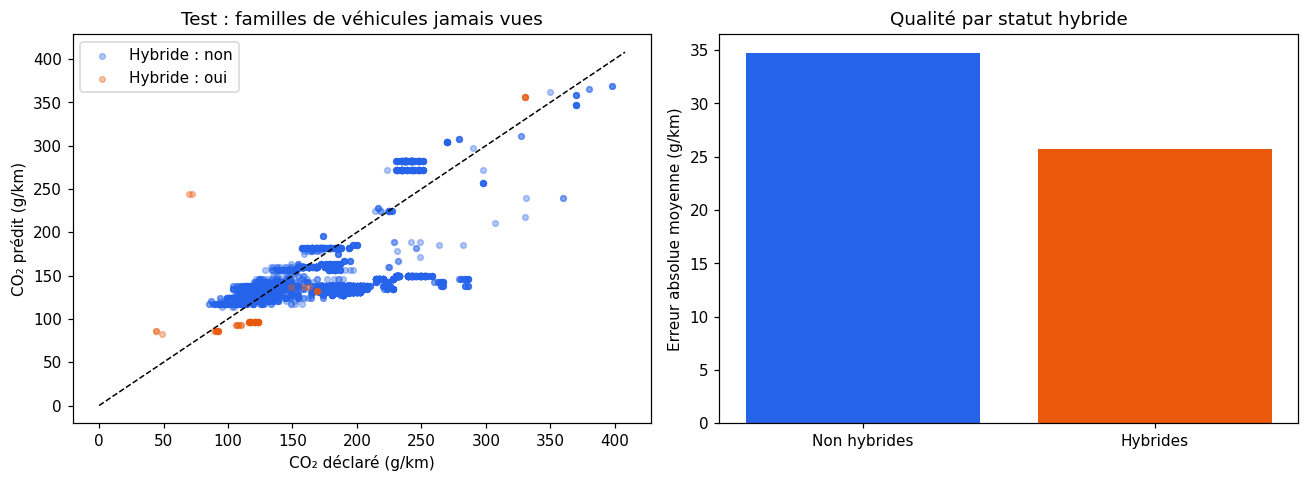

In [5]:
evaluation = donnees.loc[test, ['puiss_admin', 'hybride', cible]].copy()
evaluation['famille'] = groupes[test]
evaluation['prediction'] = modele.predict(X[test])
evaluation['reference'] = reference.predict(X[test])
evaluation['erreur_absolue'] = (evaluation[cible] - evaluation.prediction).abs()
evaluation['rayon'] = evaluation.hybride.map(rayons)
evaluation['borne_basse'] = (evaluation.prediction - evaluation.rayon).clip(lower=0)
evaluation['borne_haute'] = evaluation.prediction + evaluation.rayon
evaluation['couvert'] = evaluation[cible].between(evaluation.borne_basse, evaluation.borne_haute)
metriques = []
for nom, partie in [('Tous', evaluation), ('Non hybrides', evaluation[evaluation.hybride.eq('non')]), ('Hybrides', evaluation[evaluation.hybride.eq('oui')])]:
    metriques.append({
        'population': nom, 'lignes': len(partie), 'familles': partie.famille.nunique(),
        'MAE_g_km': mean_absolute_error(partie[cible], partie.prediction),
        'MAE_reference_g_km': mean_absolute_error(partie[cible], partie.reference),
        'RMSE_g_km': np.sqrt(mean_squared_error(partie[cible], partie.prediction)),
        'R2': r2_score(partie[cible], partie.prediction),
        'MAE_moyenne_familles': partie.groupby('famille').erreur_absolue.mean().mean(),
        'couverture_plage_pct': 100 * partie.couvert.mean(),
    })
metriques = pd.DataFrame(metriques)
print(metriques.round(2).to_string(index=False))

diagnostic_familles = evaluation.groupby('famille').agg(
    lignes=('erreur_absolue', 'size'), MAE=('erreur_absolue', 'mean'),
    co2_moyen=(cible, 'mean'), prediction_moyenne=('prediction', 'mean')
).sort_values('lignes', ascending=False)
print('\nFamilles les plus représentées dans le test :')
print(diagnostic_familles.head(8).round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for etiquette, couleur in [('non', '#2563eb'), ('oui', '#ea580c')]:
    partie = evaluation[evaluation.hybride.eq(etiquette)]
    axes[0].scatter(partie[cible], partie.prediction, alpha=0.35, s=14, color=couleur, label=f'Hybride : {etiquette}')
limite = max(evaluation[cible].max(), evaluation.prediction.max()) + 10
axes[0].plot([0, limite], [0, limite], color='black', linestyle='--', linewidth=1)
axes[0].set(xlabel='CO₂ déclaré (g/km)', ylabel='CO₂ prédit (g/km)', title='Test : familles de véhicules jamais vues')
axes[0].legend()
axes[1].bar(['Non hybrides', 'Hybrides'], metriques.set_index('population').loc[['Non hybrides', 'Hybrides'], 'MAE_g_km'], color=['#2563eb', '#ea580c'])
axes[1].set(ylabel='Erreur absolue moyenne (g/km)', title='Qualité par statut hybride')
fig.tight_layout()
fig.savefig(sortie / 'evaluation_co2.png', dpi=160)
plt.show()

## Une fonction utilisable sur une fiche incomplète

La fonction refuse les combinaisons absentes de l'entraînement ou représentées par moins de trois familles, au lieu d'extrapoler silencieusement. Ce seuil est une règle prudente du prototype, pas une garantie statistique. Les autres profils faiblement représentés restent signalés. Les nombres de familles sont ceux de l'entraînement, jamais ceux du test.

**Périmètre obligatoire : véhicules comparables au catalogue 2015, hors électriques purs.** L'interface à deux entrées ne peut pas déduire seule l'âge ou la technologie exacte ; un utilisateur doit vérifier ce périmètre avant utilisation.

In [6]:
support = donnees.loc[train, colonnes].copy()
support['famille'] = groupes[train]
support = support.groupby(colonnes).agg(lignes=('famille', 'size'), familles=('famille', 'nunique'))

def predire_co2(chevaux_fiscaux, hybride, km_annuels=15000):
    """Estimation indicative pour le périmètre du catalogue 2015, hors électriques purs."""
    if isinstance(chevaux_fiscaux, bool) or not isinstance(chevaux_fiscaux, numbers.Real) or not np.isfinite(chevaux_fiscaux) or chevaux_fiscaux <= 0 or int(chevaux_fiscaux) != chevaux_fiscaux:
        raise ValueError('Les chevaux fiscaux doivent être un entier strictement positif.')
    if isinstance(hybride, bool):
        hybride = 'oui' if hybride else 'non'
    elif isinstance(hybride, str):
        hybride = hybride.strip().lower()
    if hybride not in ('oui', 'non'):
        raise ValueError('Hybride doit valoir oui/non ou True/False.')
    if isinstance(km_annuels, bool) or not isinstance(km_annuels, numbers.Real) or not np.isfinite(km_annuels) or km_annuels < 0:
        raise ValueError('Le kilométrage annuel doit être un nombre fini positif ou nul.')
    cle = (int(chevaux_fiscaux), hybride)
    if cle not in support.index:
        return {'statut': 'non estimable', 'motif': "Combinaison absente de l'entraînement : retrouver la fiche officielle."}
    n, familles = int(support.loc[cle, 'lignes']), int(support.loc[cle, 'familles'])
    if familles < 3:
        return {'statut': 'non estimable', 'motif': 'Moins de trois familles comparables : retrouver la fiche officielle.', 'familles': familles, 'lignes': n}
    entree = pd.DataFrame({'puiss_admin': [int(chevaux_fiscaux)], 'hybride': [hybride]})
    valeur = float(modele.predict(entree)[0])
    rayon = rayons[hybride]
    bas, haut = max(0.0, valeur - rayon), valeur + rayon
    return {
        'statut': 'estimation indicative', 'cv': int(chevaux_fiscaux), 'hybride': hybride,
        'usage': 'Prototype exploratoire ; validation globale insuffisante pour un préremplissage automatique.',
        'co2_g_km': round(valeur, 1), 'plage_g_km': [round(bas, 1), round(haut, 1)],
        'lignes_comparables': n, 'familles_comparables': familles,
        'support_limite': familles < 5 or n < 30,
        'km_annuels': km_annuels,
        'scenario_tonnes_an': round(valeur * km_annuels / 1_000_000, 2),
        'plage_scenario_tonnes_an': [round(bas * km_annuels / 1_000_000, 2), round(haut * km_annuels / 1_000_000, 2)],
    }

# Modifier ces valeurs pour étudier une fiche. Comparer deux profils n'est pas une preuve d'effet causal.
exemples = [predire_co2(7, False), predire_co2(7, True), predire_co2(80, True)]
for exemple in exemples:
    print(json.dumps(exemple, ensure_ascii=False, indent=2))

{
  "statut": "estimation indicative",
  "cv": 7,
  "hybride": "non",
  "usage": "Prototype exploratoire ; validation globale insuffisante pour un préremplissage automatique.",
  "co2_g_km": 127.7,
  "plage_g_km": [
    84.6,
    170.8
  ],
  "lignes_comparables": 1729,
  "familles_comparables": 77,
  "support_limite": false,
  "km_annuels": 15000,
  "scenario_tonnes_an": 1.92,
  "plage_scenario_tonnes_an": [
    1.27,
    2.56
  ]
}
{
  "statut": "estimation indicative",
  "cv": 7,
  "hybride": "oui",
  "usage": "Prototype exploratoire ; validation globale insuffisante pour un préremplissage automatique.",
  "co2_g_km": 93.1,
  "plage_g_km": [
    62.8,
    123.4
  ],
  "lignes_comparables": 14,
  "familles_comparables": 5,
  "support_limite": true,
  "km_annuels": 15000,
  "scenario_tonnes_an": 1.4,
  "plage_scenario_tonnes_an": [
    0.94,
    1.85
  ]
}
{
  "statut": "non estimable",
  "motif": "Combinaison absente de l'entraînement : retrouver la fiche officielle."
}


## Export et vérifications

On conserve exactement le modèle évalué : il n'est pas réentraîné sur le test ou la calibration après l'évaluation. Le fichier joblib contient le pipeline, les rayons d'erreur, les effectifs et le périmètre. L'utiliser via la fonction et ses contrôles ; un appel brut à `predict` ne protège pas contre l'extrapolation. Charger uniquement un fichier joblib de confiance.

In [7]:
assert predire_co2(80, True)['statut'] == 'non estimable'
assert predire_co2(999, False)['statut'] == 'non estimable'
assert predire_co2(7, False, 0)['scenario_tonnes_an'] == 0
assert predire_co2(7, True)['co2_g_km'] == predire_co2(7, ' OUI ')['co2_g_km']
for arguments in [(0, True), (7.5, False), (True, False), (7, 'inconnu'), (7, False, -1)]:
    try:
        predire_co2(*arguments)
    except ValueError:
        pass
    else:
        raise AssertionError(f'Entrée invalide acceptée : {arguments}')

comparaison.to_csv(sortie / 'comparaison_validation.csv', sep=';', index=False)
metriques.to_csv(sortie / 'metriques_test.csv', sep=';', index=False)
evaluation.to_csv(sortie / 'predictions_test.csv', sep=';', index=False)
diagnostic_familles.to_csv(sortie / 'diagnostic_familles.csv', sep=';')
support.to_csv(sortie / 'support_entrainement.csv', sep=';')
donnees[['cnit', 'mrq_utac', 'mod_utac']].assign(partition=np.where(test, 'test', np.where(calibration, 'calibration', 'entrainement'))).to_csv(sortie / 'partitions.csv', sep=';', index=False)
artefact = {'modele': modele, 'nom': nom_retenu, 'rayons': rayons, 'support': support,
            'colonnes': colonnes, 'sklearn_version': sklearn.__version__,
            'perimetre': 'Catalogue mars 2015, hors électriques purs ; CO2 déclaré, pas émissions réelles ni cycle de vie.'}
joblib.dump(artefact, sortie / 'modele_co2.joblib')
recharge = joblib.load(sortie / 'modele_co2.joblib')
np.testing.assert_allclose(recharge['modele'].predict(X[test].head()), modele.predict(X[test].head()))
(sortie / 'exemples.json').write_text(json.dumps(exemples, ensure_ascii=False, indent=2), encoding='utf-8')
print('Exports créés dans', sortie, '— contrôles réussis.')

Exports créés dans prediction_co2 — contrôles réussis.


## Conclusion métier et suite du projet

Comparer d'abord l'erreur à la précision utile pour la décision. Une bonne moyenne globale ne suffit pas : regarder les erreurs hybrides, les familles peu représentées et la couverture de la plage. Des plages qui se chevauchent ne permettent pas un classement fiable des véhicules.

Sur cette séparation fixée à l'avance, les résultats montrent une **validation insuffisante pour automatiser le préremplissage** : R² global négatif et couverture de la plage très inférieure aux 90 % visés sur la calibration. La MAE est meilleure que celle de la médiane apprise sur l'entraînement, mais cela ne suffit pas à valider l'usage. Le R² compare les erreurs quadratiques à la moyenne du test, une autre référence, indisponible en utilisation réelle.

Les nombreuses variantes SPRINTER et CRAFTER présentes au test sont nettement sous-estimées. Cela révèle que les deux entrées ne distinguent pas assez les familles de véhicules. On conserve ces résultats et cette séparation ; on ne retire pas ces familles pour améliorer artificiellement le score. Une fois le test inspecté, toute évolution du modèle nécessitera une nouvelle validation indépendante.

Le livrable est donc un **prototype exploratoire avec diagnostic d'échec**, utile pour concevoir la collecte d'informations d'un inventaire ancien. Il ne suffit pas à décider un remplacement de véhicule ou à établir un bilan carbone officiel. La valeur ajoutée doit être comparée au coût de retrouver le CNIT ou la fiche d'homologation.

Prochaine expérience : mesurer, avec les mêmes familles séparées, l'apport du carburant, de la masse et du type d'hybridation. Pour une flotte actuelle, il faut un catalogue récent et une validation temporelle. Pour les émissions réelles, il faut une cible issue de mesures d'usage, avec trajets, consommation et recharge. Augmenter la complexité du modèle seul ne résout pas ces limites.